In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# 中文显示设置
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

print("库导入成功")


库导入成功


In [8]:
# 读取Excel数据（用绝对路径）
df = pd.read_excel(r'C:\Users\86136\Desktop\ecommerce-user-behavior-analysis\data\Online Retail.xlsx')

print(f"数据形状：{df.shape}")
print(f"\n字段类型：\n{df.dtypes}")
print(f"\n前5行：")
df.head()


数据形状：(541909, 8)

字段类型：
InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[us]
UnitPrice             float64
CustomerID            float64
Country                   str
dtype: object

前5行：


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [9]:
print("===== 数据清洗 =====")

# 1. 查看缺失值
print(f"\n缺失值统计：\n{df.isnull().sum()}")

# 2. 删除CustomerID缺失的记录（无法做用户分析）
df = df.dropna(subset=['CustomerID'])
print(f"\n删除缺失CustomerID后：{len(df)} 条")

# 3. 删除取消订单（InvoiceNo以C开头，Quantity为负数）
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]
print(f"删除取消订单后：{len(df)} 条")

# 4. 删除数量和价格为0或负的异常值
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]
print(f"删除异常值后：{len(df)} 条")

# 5. 计算每笔消费金额
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

# 6. 处理日期
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['date'] = df['InvoiceDate'].dt.date
df['hour'] = df['InvoiceDate'].dt.hour
df['month'] = df['InvoiceDate'].dt.month

# 7. CustomerID转整数
df['CustomerID'] = df['CustomerID'].astype(int)

print(f"\n清洗完成！最终数据量：{len(df)} 条")
print(f"用户数：{df['CustomerID'].nunique()}")
print(f"商品数：{df['StockCode'].nunique()}")
print(f"时间范围：{df['date'].min()} 至 {df['date'].max()}")
df.head()


===== 数据清洗 =====

缺失值统计：
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

删除缺失CustomerID后：406829 条
删除取消订单后：397924 条
删除异常值后：397884 条

清洗完成！最终数据量：397884 条
用户数：4338
商品数：3665
时间范围：2010-12-01 至 2011-12-09


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice,date,hour,month
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30,2010-12-01,8,12
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010-12-01,8,12
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00,2010-12-01,8,12
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010-12-01,8,12
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010-12-01,8,12


每日销售数据（前10天）：
         date       销售额  订单数     客单价
0  2010-12-01  46376.49  121  383.28
1  2010-12-02  47316.53  137  345.38
2  2010-12-03  23921.71   57  419.68
3  2010-12-05  31771.60   87  365.19
4  2010-12-06  31215.64   94  332.08
5  2010-12-07  53795.31   71  757.68
6  2010-12-08  39248.82  111  353.59
7  2010-12-09  38231.90   98  390.12
8  2010-12-10  33650.28   72  467.36
9  2010-12-12  17305.77   43  402.46


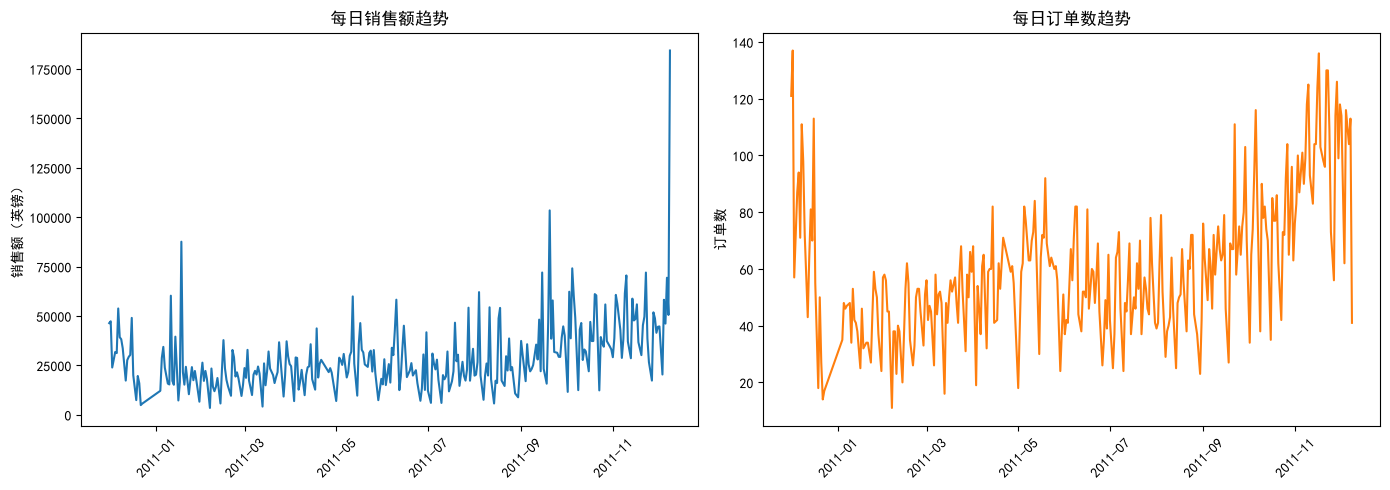

In [10]:
# 每日销售额
daily_sales = df.groupby('date')['TotalPrice'].sum().reset_index()
daily_sales.columns = ['date', '销售额']

# 每日订单数
daily_orders = df.groupby('date')['InvoiceNo'].nunique().reset_index()
daily_orders.columns = ['date', '订单数']

daily_flow = pd.merge(daily_sales, daily_orders, on='date')
daily_flow['客单价'] = (daily_flow['销售额'] / daily_flow['订单数']).round(2)

print("每日销售数据（前10天）：")
print(daily_flow.head(10))

# 画图
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(daily_flow['date'], daily_flow['销售额'], color='#1f77b4')
plt.title('每日销售额趋势')
plt.xticks(rotation=45)
plt.ylabel('销售额（英镑）')

plt.subplot(1, 2, 2)
plt.plot(daily_flow['date'], daily_flow['订单数'], color='#ff7f0e')
plt.title('每日订单数趋势')
plt.xticks(rotation=45)
plt.ylabel('订单数')

plt.tight_layout()
plt.savefig('images/sales_trend.png', dpi=150, bbox_inches='tight')
plt.show()


RFM用户分层结果：
     用户分层   用户数       平均消费金额    平均消费频次  用户占比  金额贡献占比
4  重要价值用户  1319  4932.935550  9.376801  30.4    73.0
5  重要保持用户   448  2136.950647  4.685268  10.3    10.7
7  重要挽留用户   264  1565.906292  1.553030   6.1     4.6
3  一般挽留用户  1240   285.280307  1.187097  28.6     4.0
6  重要发展用户   138  2435.839275  1.797101   3.2     3.8
2  一般发展用户   527   314.625047  1.356736  12.1     1.9
0  一般价值用户   204   464.868431  3.058824   4.7     1.1
1  一般保持用户   198   422.115157  3.010101   4.6     0.9

重要价值用户占比：30.4%，贡献销售额：73.0%


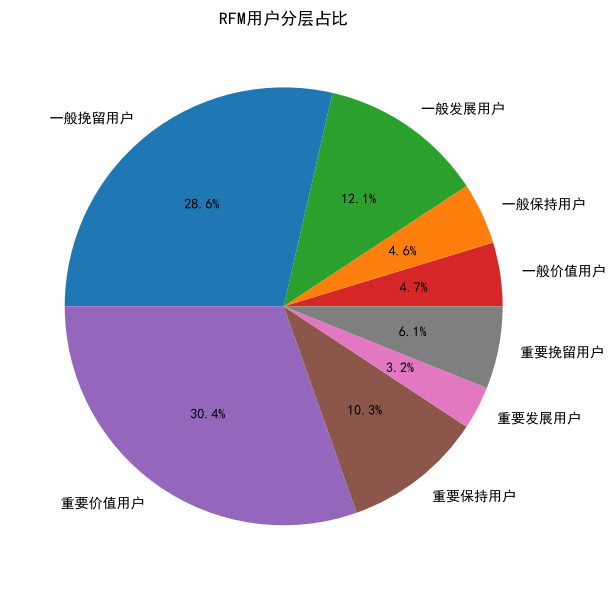

In [11]:
# 计算RFM指标
# 假设分析截止日期为数据最后一天+1天
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

# R：最近一次消费距今天数
# F：消费频次（订单数）
# M：消费总金额
rfm = df.groupby('CustomerID').agg(
    最近消费时间=('InvoiceDate', 'max'),
    消费频次=('InvoiceNo', 'nunique'),
    消费总金额=('TotalPrice', 'sum')
).reset_index()

rfm['R'] = (snapshot_date - rfm['最近消费时间']).dt.days
rfm = rfm.rename(columns={'消费频次': 'F', '消费总金额': 'M'})

# RFM打分（R越小越好，F和M越大越好）
rfm['R_score'] = pd.qcut(rfm['R'], q=4, labels=[4, 3, 2, 1])
rfm['F_score'] = pd.qcut(rfm['F'].rank(method='first'), q=4, labels=[1, 2, 3, 4])
rfm['M_score'] = pd.qcut(rfm['M'], q=4, labels=[1, 2, 3, 4])

# 转成整数
rfm['R_score'] = rfm['R_score'].astype(int)
rfm['F_score'] = rfm['F_score'].astype(int)
rfm['M_score'] = rfm['M_score'].astype(int)

# RFM总分
rfm['RFM总分'] = rfm['R_score'] + rfm['F_score'] + rfm['M_score']

# 用户分层
def rfm_segment(row):
    if row['R_score'] >= 3 and row['F_score'] >= 3 and row['M_score'] >= 3:
        return '重要价值用户'
    elif row['R_score'] >= 3 and row['F_score'] < 3 and row['M_score'] >= 3:
        return '重要发展用户'
    elif row['R_score'] < 3 and row['F_score'] >= 3 and row['M_score'] >= 3:
        return '重要保持用户'
    elif row['R_score'] < 3 and row['F_score'] < 3 and row['M_score'] >= 3:
        return '重要挽留用户'
    elif row['R_score'] >= 3 and row['F_score'] >= 3 and row['M_score'] < 3:
        return '一般价值用户'
    elif row['R_score'] >= 3 and row['F_score'] < 3 and row['M_score'] < 3:
        return '一般发展用户'
    elif row['R_score'] < 3 and row['F_score'] >= 3 and row['M_score'] < 3:
        return '一般保持用户'
    else:
        return '一般挽留用户'

rfm['用户分层'] = rfm.apply(rfm_segment, axis=1)

# 统计各层级
segment_stats = rfm.groupby('用户分层').agg(
    用户数=('CustomerID', 'count'),
    平均消费金额=('M', 'mean'),
    平均消费频次=('F', 'mean')
).reset_index()
segment_stats['用户占比'] = (segment_stats['用户数'] / segment_stats['用户数'].sum() * 100).round(1)
segment_stats['金额贡献占比'] = (segment_stats['用户数'] * segment_stats['平均消费金额'] / 
                              (segment_stats['用户数'] * segment_stats['平均消费金额']).sum() * 100).round(1)

print("RFM用户分层结果：")
print(segment_stats.sort_values('金额贡献占比', ascending=False))

# 高价值用户贡献
high_value = segment_stats[segment_stats['用户分层'] == '重要价值用户']
print(f"\n重要价值用户占比：{high_value['用户占比'].values[0]}%，贡献销售额：{high_value['金额贡献占比'].values[0]}%")

# 画图
plt.figure(figsize=(10, 6))
colors = ['#d62728', '#ff7f0e', '#2ca02c', '#1f77b4', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f']
plt.pie(segment_stats['用户数'], labels=segment_stats['用户分层'], 
        autopct='%1.1f%%', colors=colors[:len(segment_stats)])
plt.title('RFM用户分层占比')
plt.tight_layout()
plt.savefig('images/rfm.png', dpi=150, bbox_inches='tight')
plt.show()


热销商品TOP10（按销售额）：
                             Description   销售数量        销售额
2319         PAPER CRAFT , LITTLE BIRDIE  80995  168469.60
2767            REGENCY CAKESTAND 3 TIER  12402  142592.95
3698  WHITE HANGING HEART T-LIGHT HOLDER  36725  100448.15
1762             JUMBO BAG RED RETROSPOT  46181   85220.78
1992      MEDIUM CERAMIC TOP STORAGE JAR  77916   81416.73
2611                             POSTAGE   3120   77803.96
2345                       PARTY BUNTING  15291   68844.33
216        ASSORTED COLOUR BIRD ORNAMENT  35362   56580.34
2130                              Manual   7173   53779.93
2656                  RABBIT NIGHT LIGHT  27202   51346.20


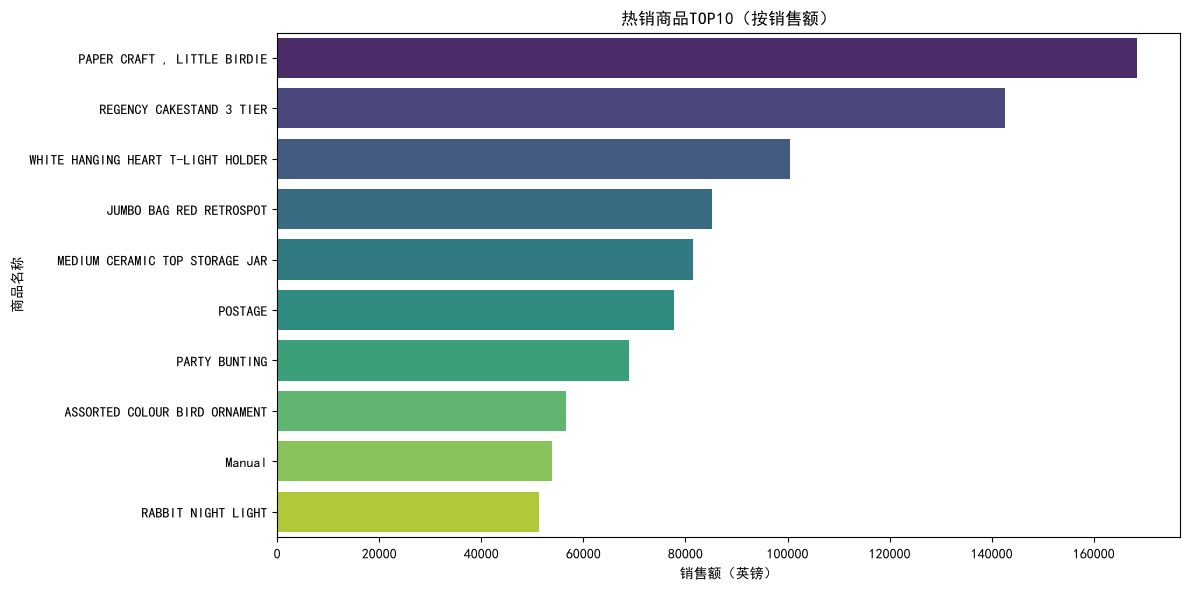

In [13]:
# 按销售额统计TOP10商品
top_products = df.groupby('Description').agg(
    销售数量=('Quantity', 'sum'),
    销售额=('TotalPrice', 'sum')
).reset_index().sort_values('销售额', ascending=False).head(10)

print("热销商品TOP10（按销售额）：")
print(top_products)

# 画图
plt.figure(figsize=(12, 6))
sns.barplot(data=top_products, y='Description', x='销售额', palette='viridis')
plt.title('热销商品TOP10（按销售额）')
plt.xlabel('销售额（英镑）')
plt.ylabel('商品名称')
plt.tight_layout()
plt.savefig('images/top_products.png', dpi=150, bbox_inches='tight')
plt.show()


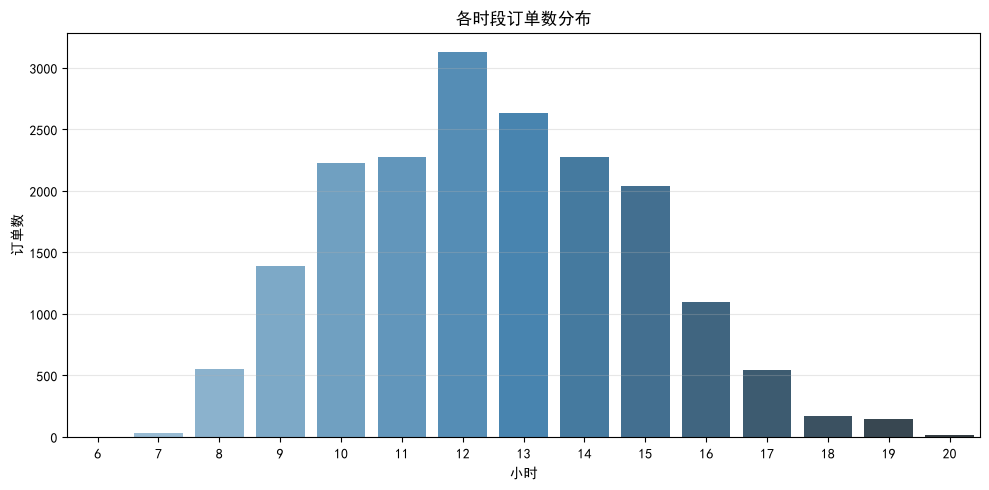

订单高峰时段：12点


In [14]:
# 各时段订单数
hourly_orders = df.groupby('hour')['InvoiceNo'].nunique().reset_index()

plt.figure(figsize=(10, 5))
sns.barplot(data=hourly_orders, x='hour', y='InvoiceNo', palette='Blues_d')
plt.title('各时段订单数分布')
plt.xlabel('小时')
plt.ylabel('订单数')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('images/hourly_orders.png', dpi=150, bbox_inches='tight')
plt.show()

peak_hour = hourly_orders.loc[hourly_orders['InvoiceNo'].idxmax(), 'hour']
print(f"订单高峰时段：{peak_hour}点")


用户复购率（订单数>=2）：65.6%

用户订单数分布：
订单数
1     1493
2      835
3      508
4      388
5      242
6      172
7      143
8       98
9       68
10      54
Name: count, dtype: int64


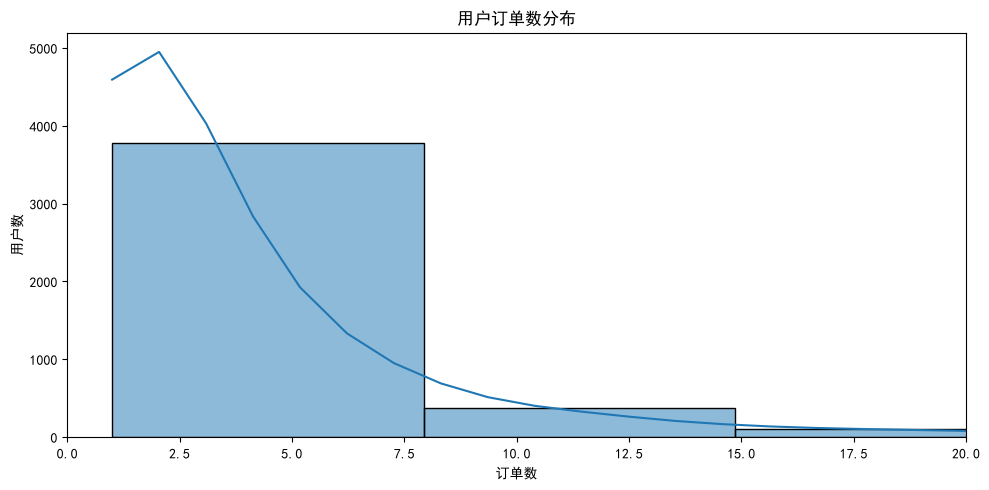

In [15]:
# 用户订单数分布
user_orders = df.groupby('CustomerID')['InvoiceNo'].nunique().reset_index()
user_orders.columns = ['CustomerID', '订单数']

# 复购率（订单数>=2的用户占比）
repurchase_rate = (user_orders['订单数'] >= 2).mean() * 100
print(f"用户复购率（订单数>=2）：{repurchase_rate:.1f}%")

# 订单数分布
order_dist = user_orders['订单数'].value_counts().sort_index().head(10)
print(f"\n用户订单数分布：")
print(order_dist)

# 画图
plt.figure(figsize=(10, 5))
sns.histplot(user_orders['订单数'], bins=30, kde=True, color='#1f77b4')
plt.title('用户订单数分布')
plt.xlabel('订单数')
plt.ylabel('用户数')
plt.xlim(0, 20)
plt.tight_layout()
plt.savefig('images/repurchase.png', dpi=150, bbox_inches='tight')
plt.show()
